In [1]:
try: 
    import kagglehub #pip install kagglehub
    kagglehub.login()
    path = kagglehub.competition_download('aca-butterflies')
    print("Path to dataset files:", path)
    
except ImportError as e:
    from pathlib import Path
    path = Path().cwd()  / "aca-butterflies"

Path to dataset files: /Users/jfranciscocmorais/.cache/kagglehub/competitions/aca-butterflies


In [2]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.utils.data as data
import torchvision.transforms as transforms

In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = 64

In [4]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

In [5]:
# load the data
img_dir = os.path.join(path, 'train')
df = pd.read_csv(os.path.join(path, 'train.csv'))

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# encapsulate data into dataloader form
dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [6]:
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


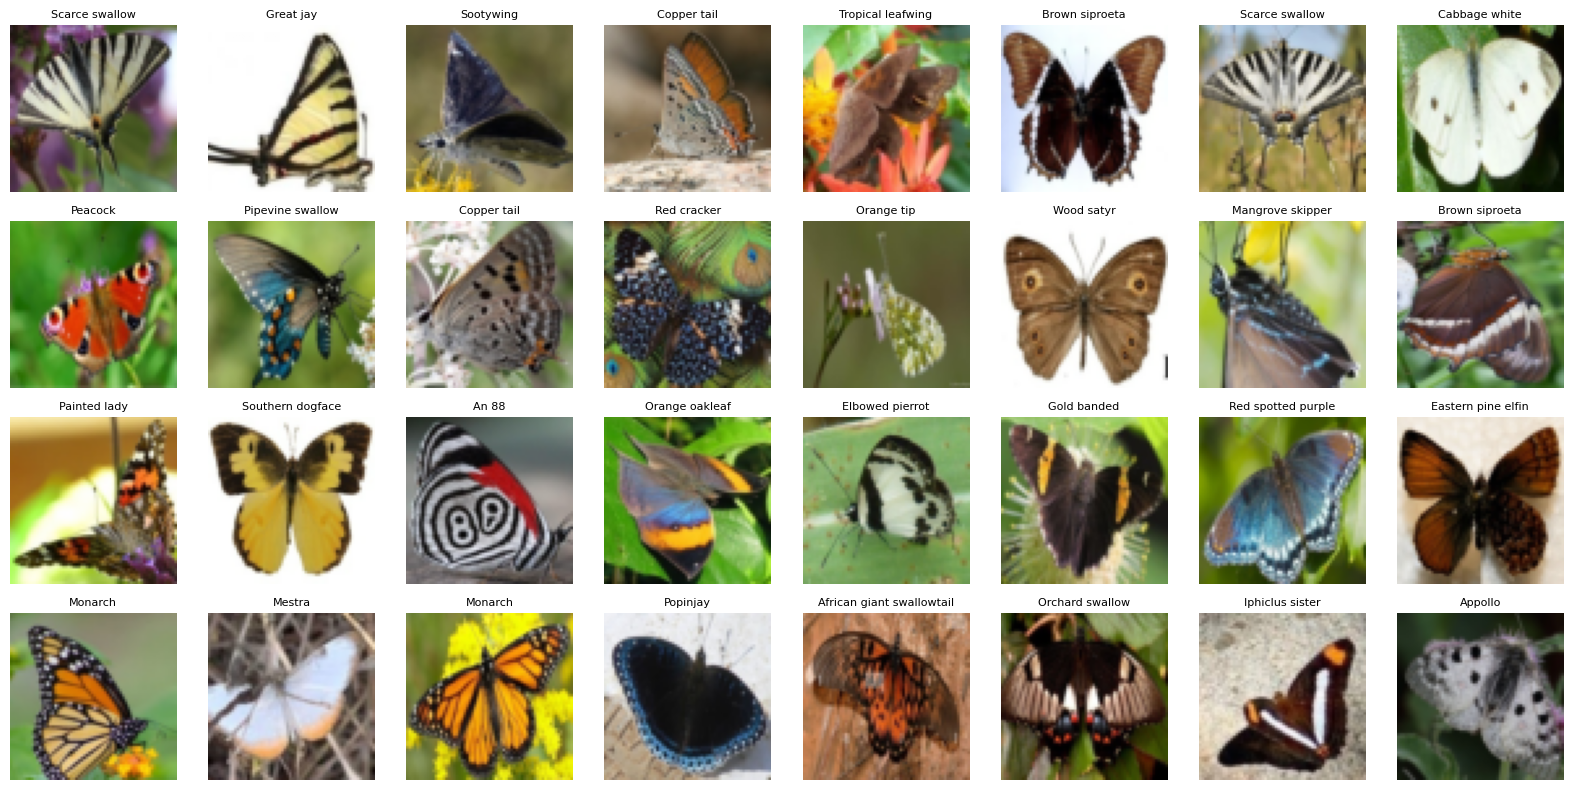

In [7]:
# Get a batch of images from the dataloader
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(len(images)):
    img = images[i].permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]

    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# 1. MLP